In [30]:
import importlib
import modules.simple_training as simple_training

from modules.simple_training import TrainingConfig, train_validate_test
importlib.reload(simple_training)

data_path = "./data/data_scaled.csv"

config = TrainingConfig(
    hidden_sizes=[32, 32],
    hidden_activation="relu",  # change to "tanh", "sigmoid", or "relu"
    output_activation="linear",  # used for mse; cross-entropy uses logits automatically
    loss_name="cross_entropy",  # change to "cross_entropy" for classification-style training
    learning_rate=0.01,
    epochs=500,
    batch_size=16,  # None = use the whole training split in one batch
    test_size=0.2,
    val_size=0.2,
    random_state=42,
)

model, history, metrics, classes = train_validate_test(data_path, config)

print("Classes:", classes)
print("Final train loss:", history["train_loss"][-1])
print("Final val loss:", history["val_loss"][-1])
print("Test loss:", metrics["test_loss"])
print("Test accuracy:", metrics["test_accuracy"])


Classes: [0 1 2 3 4 5]
Final train loss: 0.8360098722099266
Final val loss: 1.1191133159336752
Test loss: 1.185998788638567
Test accuracy: 0.5392156862745098


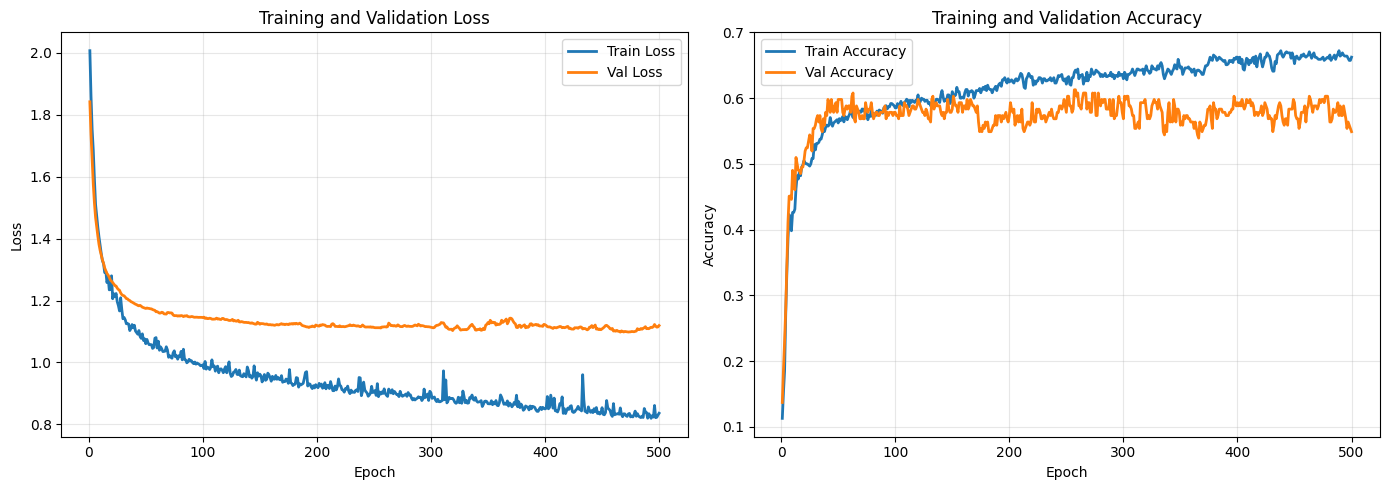

Best val loss: 1.098000 at epoch 466
Best val accuracy: 61.27% at epoch 257


In [31]:
import matplotlib.pyplot as plt
import numpy as np
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
epochs_range = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_range, history["train_loss"], label="Train Loss", linewidth=2)
ax1.plot(epochs_range, history["val_loss"], label="Val Loss", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(epochs_range, history["train_accuracy"], label="Train Accuracy", linewidth=2)
ax2.plot(epochs_range, history["val_accuracy"], label="Val Accuracy", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training and Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best val loss: {min(history['val_loss']):.6f} at epoch {np.argmin(history['val_loss']) + 1}")
print(f"Best val accuracy: {max(history['val_accuracy']):.2%} at epoch {np.argmax(history['val_accuracy']) + 1}")
